In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install mahotas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 102.3 MB/s eta 0:00:00


Box(children=(GridBox(children=(HTML(value="\n<h1 style='text-align:center'>\nClassificação de Imagens\n</h1>\…



Características carregadas de: /content/drive/MyDrive/Colab Notebooks/VC/Projeto Final/features/haralick/PetImages/train/features.npy
Rótulos e encoder carregados de: /content/drive/MyDrive/Colab Notebooks/VC/Projeto Final/features/haralick/PetImages/train/rotulos_labelenc.npy
Treinando o modelo SVM...
Treinamento encerrado em 0.15s
Diretório já existe: /content/drive/MyDrive/Colab Notebooks/VC/Projeto Final/modelos/svm/PetImages
Salvando modelo...
Modelo salvo em: /content/drive/MyDrive/Colab Notebooks/VC/Projeto Final/modelos/svm/PetImages/svm_haralick.pkl




Características carregadas de: /content/drive/MyDrive/Colab Notebooks/VC/Projeto Final/features/haralick/PetImages/test/features.npy
Rótulos e encoder carregados de: /content/drive/MyDrive/Colab Notebooks/VC/Projeto Final/features/haralick/PetImages/test/rotulos_labelenc.npy
Modelo carregado de: /content/drive/MyDrive/Colab Notebooks/VC/Projeto Final/modelos/svm/PetImages/svm_haralick.pkl
Iniciando previsão...
Previsão encerrada em 0.14s


Diretório já existe: /content/drive/MyDrive/Colab Notebooks/VC/Projeto Final/resultados/svm/PetImages


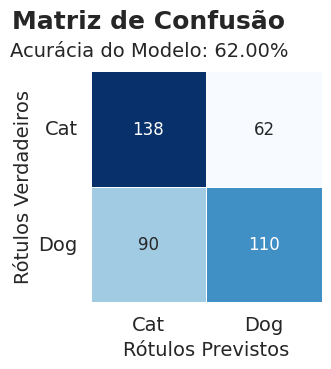



Diretório já existe: /content/drive/MyDrive/Colab Notebooks/VC/Projeto Final/resultados/svm/PetImages


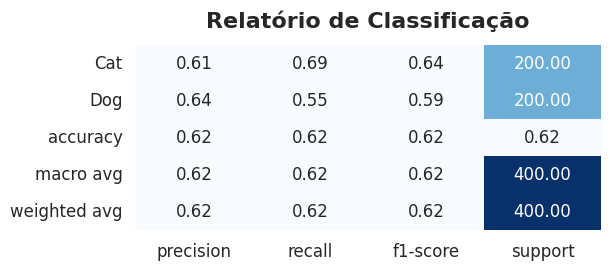

In [3]:
# @title
import ipywidgets as widgets
from IPython.display import display, HTML
import matplotlib.pyplot as plt
from sklearn import preprocessing
import numpy as np
import sys
import os

#####################
# MONTAGEM DO DRIVE #
#####################
from google.colab import drive
if not os.path.ismount('/content/drive'):
    print("Montando o Google Drive...")
    drive.mount('/content/drive')

###########################
# CARREGAMENTO DE MÓDULOS #
###########################

# Caminho dos módulos do projeto armazenados no Google Drive
caminho_modulos = '/content/drive/MyDrive/Colab Notebooks/VC/Projeto Final/modulos'
from pydoc import importfile
# Importação de módulos Python
haralick_module = importfile(caminho_modulos+'/descritores/haralick.py')
svm_module = importfile(caminho_modulos+'/classificadores/svm.py')
dados_utils = importfile(caminho_modulos+'/utils/dados.py')
rotulos_utils = importfile(caminho_modulos+'/utils/rotulos.py')
metricas_utils = importfile(caminho_modulos+'/utils/metricas.py')

########################################################################
# CAMINHOS GLOBAIS
########################################################################

caminho_base = '/content/drive/MyDrive/Colab Notebooks/VC/Projeto Final'
caminho_todos_datasets = caminho_base + '/dataset/'
selected_dataset = 'PetImages'

def configurar_caminhos(caminho_base, dataset, caracteristica):
    """
    Configura variáveis globais com base no caminho base, no nome do dataset e na característica fornecidos.

    Parâmetros:
    - caminho_base (str): O caminho base para o diretório onde os arquivos estão armazenados.
    - dataset (str): O nome do dataset (por exemplo, 'covid19', 'outro_dataset', etc.)
    - caracteristica (str): O nome da característica (por exemplo, 'sift', 'hog', etc.)
    """
    global caminho_dataset_treinamento
    global caminho_dataset_teste
    global caminho_features_treinamento
    global caminho_features_teste
    global caminho_rotulos_treinamento_label
    global caminho_rotulos_teste_label
    global caminho_rotulos_treinamento_onehot
    global caminho_rotulos_teste_onehot
    global caminho_modelo_svm_treinado
    global caminho_resultado_svm_mc
    global caminho_resultado_svm_rc

    # Caminho dos datasets armazenados no Google Drive
    caminho_dataset_treinamento = f'{caminho_base}/dataset/{dataset}/train'
    caminho_dataset_teste = f'{caminho_base}/dataset/{dataset}/test'

    # Caminho das features extraídas armazenadas no Google Drive
    caminho_features_treinamento = f'{caminho_base}/features/{caracteristica}/{dataset}/train/features.npy'
    caminho_features_teste = f'{caminho_base}/features/{caracteristica}/{dataset}/test/features.npy'

    # Caminho dos rótulos extraídos armazenados no Google Drive
    caminho_rotulos_treinamento_label = f'{caminho_base}/features/{caracteristica}/{dataset}/train/rotulos_labelenc.npy'
    caminho_rotulos_teste_label = f'{caminho_base}/features/{caracteristica}/{dataset}/test/rotulos_labelenc.npy'
    caminho_rotulos_treinamento_onehot = f'{caminho_base}/features/{caracteristica}/{dataset}/train/rotulos_onehotenc.npy'
    caminho_rotulos_teste_onehot = f'{caminho_base}/features/{caracteristica}/{dataset}/test/rotulos_onehotenc.npy'

    # Caminho dos modelos treinados armazenados no Google Drive
    caminho_modelo_svm_treinado = f'{caminho_base}/modelos/svm/{dataset}/svm_{caracteristica}.pkl'

    # Caminho dos resultados armazenados no Google Drive
    caminho_resultado_svm_mc = f'{caminho_base}/resultados/svm/{dataset}/svm_{caracteristica}_mc.png'
    caminho_resultado_svm_rc = f'{caminho_base}/resultados/svm/{dataset}/svm_{caracteristica}_rc.png'

# FUNÇÕES CALLBACK ASSOCIADAS AOS ITENS DA INTERFACE DO  USUÁRIO #
##################################################################

def extrair_caracteristicas_treinamento(imagens, rotulos):
    """
    Extrai características de treinamento das imagens fornecidas e salva os resultados em arquivos.

    Parâmetros:
    - imagens (list): Lista de imagens de treinamento.
    - rotulos (list): Lista de rótulos correspondentes às imagens de treinamento.

    Retorno:
    - modelo_kmeans (MiniBatchKMeans): O modelo treinado K-Means.
    - n_grupos (int): Número de grupos (clusters) utilizados no modelo K-Means.
    """

    # Inicializa as variáveis que serão retornadas
    modelo_kmeans = None
    n_grupos = None

    # Centralizar o título
    print('\n')
    titulo= f'Extração de Características Haralick'
    display(HTML(f'<div style="text-align: left; font-size: 16px; font-weight: bold;">{titulo}</div>'))
    caracteristica = 'haralick'
    configurar_caminhos(caminho_base, selected_dataset, caracteristica)
    # Extrai características haralick e obtém modelo kmeans treinado
    caracteristicas_haralick_treinamento = haralick_module.extrair_haralick(imagens)
    print(caracteristicas_haralick_treinamento.shape)
    # Salva as características extraídas
    dados_utils.salvar_caracteristicas(caracteristicas_haralick_treinamento, caminho_features_treinamento)
    # Codifica os rótulos usando LabelEncoder salva os resultados
    rotulos_label, encoder = rotulos_utils.codificar_rotulos_label(rotulos)
    dados_utils.salvar_rotulos(rotulos_label, encoder, caminho_rotulos_treinamento_label)
    # Codifica os rótulos usando OneHotEncoder salva os resultados
    rotulos_onehot, encoder = rotulos_utils.codificar_rotulos_onehot(rotulos)
    dados_utils.salvar_rotulos(rotulos_onehot, encoder, caminho_rotulos_treinamento_onehot)

    return modelo_kmeans, n_grupos

def extrair_caracteristicas_teste(imagens, rotulos, modelo_kmeans, n_grupos):
    """
    Extrai características de teste das imagens fornecidas e salva os resultados em arquivos.

    Parâmetros:
    - imagens (list): Lista de imagens de teste.
    - rotulos (list): Lista de rótulos correspondentes às imagens de teste.
    - modelo_kmeans (MiniBatchKMeans): O modelo K-Means treinado.
    - n_grupos (int): Número de grupos (clusters) utilizados no modelo K-Means.

    Retorno:
    - None
    """
    caracteristica = 'haralick'
    configurar_caminhos(caminho_base, selected_dataset, caracteristica)
    # Extrai características haralick e obtém o modelo kmeans treinado
    caracteristicas_haralick_teste = haralick_module.extrair_haralick(imagens)
    # Salva as características extraídas
    dados_utils.salvar_caracteristicas(caracteristicas_haralick_teste, caminho_features_teste)
    # Codifica os rótulos usando LabelEncoder salva os resultados
    rotulos_label, encoder = rotulos_utils.codificar_rotulos_label(rotulos)
    dados_utils.salvar_rotulos(rotulos_label, encoder, caminho_rotulos_teste_label)
    # Codifica os rótulos usando OneHotEncoder salva os resultados
    rotulos_onehot, encoder = rotulos_utils.codificar_rotulos_onehot(rotulos)
    dados_utils.salvar_rotulos(rotulos_onehot, encoder, caminho_rotulos_teste_onehot)

def carregar_imagens_conjuntos(tipo_conjunto):
    """
    Carrega imagens e rótulos para o conjunto especificado ('treinamento' ou 'teste').

    Parâmetros:
    - tipo_conjunto (str): O tipo de conjunto a ser carregado ('treinamento' ou 'teste').

    Retorno:
    - imagens (list): Lista de imagens carregadas.
    - rotulos (list): Lista de rótulos correspondentes às imagens.
    """
    if tipo_conjunto == 'treinamento':
        # Centralizar o título
        titulo = f'CONJUNTO DE TREINAMENTO'
        display(HTML(f'<div style="text-align: center; font-size: 20px; font-weight: bold;">{titulo}</div>'))
        print('\n')
        configurar_caminhos(caminho_base, selected_dataset, None)
        # Carrega imagens e rótulos de treinamento
        imagens, rotulos = dados_utils.carregar_imagens(caminho_dataset_treinamento)
    elif tipo_conjunto == 'teste':
        # Centralizar o título
        print('\n')
        titulo = f'CONJUNTO DE TESTE'
        display(HTML(f'<div style="text-align: center; font-size: 20px; font-weight: bold;">{titulo}</div>'))
        print('\n')
        configurar_caminhos(caminho_base, selected_dataset, None)
        # Carrega imagens e rótulos de teste
        imagens, rotulos = dados_utils.carregar_imagens(caminho_dataset_teste)
    else:
        raise ValueError(f"Tipo de conjunto {tipo_conjunto} não é válido.")

    # Retorna as imagens e os rótulos correspondentes ao tipo de conjunto
    return imagens, rotulos


def extrair_caracteristicas_conjuntos():
    """
    Extrai características para os conjuntos de treinamento e teste, e salva os resultados.
    """
    limpar_outputs()
    with main_output:  # Usa o widget de saída para capturar toda a saída gerada
        # Carrega e processa o conjunto de treinamento
        imagens, rotulos = carregar_imagens_conjuntos('treinamento')
        modelo_kmeans, n_grupos = extrair_caracteristicas_treinamento(imagens, rotulos)

        # Carrega e processa o conjunto de teste
        imagens, rotulos_teste = carregar_imagens_conjuntos('teste')
        extrair_caracteristicas_teste(imagens, rotulos_teste, modelo_kmeans, n_grupos)
        display(HTML('<div style="text-align: center; color: green; padding: 10px;">Características Extraídas com Sucesso!</div>'))


def treinar_modelo(classificador, caracteristica, caminho_features_treinamento, caminho_rotulos_treinamento_label, caminho_modelo_treinado):
    """
    Treina um modelo com base no classificador e característica fornecidos.

    Parâmetros:
    - classificador (str): O classificador a ser utilizado é svm.
    - caracteristica (str): A característica a ser utilizada é haralick.
    - caminho_features_treinamento (str): Caminho para as características de treinamento.
    - caminho_rotulos_treinamento_label (str): Caminho para os rótulos de treinamento.
    - caminho_modelo_treinado (str): Caminho para salvar o modelo treinado.
    """
    print('\n')
    # Centralizar o título
    titulo = f'Treinamento {classificador.upper()} - {caracteristica.upper()}'
    display(HTML(f'<div style="text-align: center; font-size: 20px; font-weight: bold;">{titulo}</div>'))

    # Carregar características e rótulos
    caracteristicas = dados_utils.carregar_caracteristicas(caminho_features_treinamento)
    rotulos, encoder = dados_utils.carregar_rotulos(caminho_rotulos_treinamento_label)

    # Treinamento do modelo baseado no classificador
    modelo = svm_module.treinar_svm(caracteristicas, rotulos)

    # Salvar o modelo treinado
    dados_utils.salvar_modelo(modelo, caminho_modelo_treinado)

def treinar_classificadores():
    caracteristica = 'haralick'
    configurar_caminhos(caminho_base, selected_dataset, caracteristica)
    treinar_modelo('svm', 'haralick', caminho_features_treinamento, caminho_rotulos_treinamento_label, caminho_modelo_svm_treinado)
    display(HTML('<div style="text-align: center; color: green; padding: 10px;">Modelo (s) Treinado (s) com Sucesso!</div>'))

def testar_modelo(classificador, caracteristica, caminho_features_teste, caminho_rotulos_teste, caminho_modelo_treinado, caminho_resultado_mc, caminho_resultado_rc):
    """
    Função para testar o modelo com base no classificador e característica fornecidos.

    :param classificador: Tipo de classificador é svm
    :param caracteristica: Tipo de característica é haralick
    :param caminho_features_teste: Caminho para as características de teste
    :param caminho_rotulos_teste: Caminho para os rótulos de teste
    :param caminho_modelo_treinado: Caminho para o modelo treinado
    :param caminho_resultado_mc: Caminho para salvar a matriz de confusão
    :param caminho_resultado_rc: Caminho para salvar o relatório de classificação
    """
    print('\n')
    display(HTML(f'<div style="text-align: center; font-size: 20px; font-weight: bold;">Classificação - {classificador.upper()} - {caracteristica.upper()}</div>'))

    # Carregar características
    caracteristicas = dados_utils.carregar_caracteristicas(caminho_features_teste)

    # Escolher o tipo de codificação dos rótulos
    rotulos_verdadeiros, encoder = dados_utils.carregar_rotulos(caminho_rotulos_teste)

    # Carregar o modelo treinado
    try:
        modelo = dados_utils.carregar_modelo(caminho_modelo_treinado)
    except FileNotFoundError:
        print(f"Modelo não encontrado no caminho: {caminho_modelo_treinado}")
        modelo = None
    #  Fazer a previsão
    if modelo is not None:
        rotulos_previstos = svm_module.testar_svm(modelo, caracteristicas)

        # Obter os nomes das classes
        if isinstance(encoder, preprocessing.OneHotEncoder):
            # Se for OneHotEncoder, obtenha as classes diretamente do rótulo original
            nomes_das_classes = encoder.categories_[0]
        else:
            # Se for LabelEncoder, use o atributo classes_
            nomes_das_classes = encoder.classes_

        # Gerar e salvar as métricas
        print('\n')
        metricas_utils.matriz_confusao(nomes_das_classes, rotulos_verdadeiros, rotulos_previstos, caminho_resultado_mc)
        print('\n')
        metricas_utils.relatorio_classificacao(nomes_das_classes, rotulos_verdadeiros, rotulos_previstos, caminho_resultado_rc)

def testar_classificadores():
    caracteristica = 'haralick'
    configurar_caminhos(caminho_base, selected_dataset, caracteristica)
    testar_modelo(
        'svm',
        'haralick',
        caminho_features_teste,
        caminho_rotulos_teste_label,
        caminho_modelo_svm_treinado,
        caminho_resultado_svm_mc,
        caminho_resultado_svm_rc
    )

    display(HTML('<div style="text-align: center; color: green; padding: 10px;">Teste (s) encerrado (s) !</div>'))

def on_extrair_click(b):
    extrair_caracteristicas_conjuntos()

def on_treinar_click(b):
    treinar_classificadores()

def on_classificar_click(b):
    testar_classificadores()

#################################
# ITENS DA INTERFACE DO USUÁRIO #
#################################

#############
# CABEÇALHO #
#############

# Header
header = widgets.HTML(
"""
<h1 style='text-align:center'>
Classificação de Imagens
</h1>

<h3 style='text-align:center'>
Cats vs Dogs utilizando Haralick + SVM
</h3>
"""
)

###################
# ABAS PRINCIPAIS #
###################

# Criar abas
tab = widgets.Tab(
    layout=widgets.Layout(min_width='700px', min_height='50px') # Definir tamanho mínimo
)

# Definir os títulos de cada aba
tab.set_title(0, 'DATASET')
tab.set_title(1, 'EXT. CARACTERÍSTICAS')
tab.set_title(2, 'TREINAMENTO')
tab.set_title(3, 'CLASSIFICAÇÃO')

# Output widget para exibir os resultados
main_output = widgets.Output(
    layout=widgets.Layout(
        border='0px solid black',
        width='100%',
        height='60vh',  # Define a altura como 50% da altura da tela
        overflow_y='auto'  # Adiciona barra de rolagem vertical
    )
)


def limpar_outputs():
    main_output.clear_output(wait=True)


# HBox para organizar image_output, hist_output e segmentation lado a lado
outputs_box = widgets.VBox([main_output], layout=widgets.Layout(align_items='center', justify_content='center'))

# GridBox para organizar o cabeçalho, as abas e a imagem de saída
grid = widgets.GridBox(children=[header, tab, outputs_box],
               layout=widgets.Layout(
                   grid_template_rows='auto auto auto',
                   grid_template_columns='1fr',  #uma  coluna flexível para ocupar o espaço disponível.
                   justify_items='center',
                   align_items='center',
                   grid_gap='10px'
               ))

# Contêiner pai para centralizar o GridBox
container = widgets.Box([grid], layout=widgets.Layout(display='flex', justify_content='center', align_items='center', width='100%'))

# Exibir o contêiner pai
display(container)


##########################
# CONTEUDO ABA DATASET   #
##########################

info_dataset = widgets.HTML("""
<h3>Dataset Selecionado</h3>
<p><b>PetImages (Cats vs Dogs)</b></p>
<p>1000 imagens de gatos e 1000 imagens de cães.</p>
""")

#############################
# CONTEUDO ABA EXT. CARACT. #
#############################

info_descritor = widgets.HTML("""
<h3>Extrator de Características</h3>
<p><b>Haralick</b></p>
""")

botao_extrair = widgets.Button(
    description='Extrair Características',
    button_style='success'
)

botao_extrair.on_click(on_extrair_click)

opcoes_descritores = widgets.VBox([
    info_descritor,
    botao_extrair
])

#############################
# CONTEUDO ABA TREINAMENTO  #
#############################

info_treino = widgets.HTML("""
<h3>Classificador</h3>
<p><b>SVM</b></p>
""")

botao_treinar = widgets.Button(
    description='Treinar Modelo',
    button_style='success'
)

botao_treinar.on_click(on_treinar_click)

opcoes_classif_treino = widgets.VBox([
    info_treino,
    botao_treinar
])

#############################
# CONTEUDO ABA CLASSIFICACAO  #
#############################

info_classificacao = widgets.HTML("""
<h3>Classificação</h3>
<p><b>SVM + Haralick</b></p>
""")

botao_classificar = widgets.Button(
    description='Executar Teste',
    button_style='info'
)

botao_classificar.on_click(on_classificar_click)

opcoes_classif_teste = widgets.VBox([
    info_classificacao,
    botao_classificar
])

tab.children = [
    widgets.VBox([info_dataset]),
    widgets.VBox([opcoes_descritores]),
    widgets.VBox([opcoes_classif_treino]),
    widgets.VBox([opcoes_classif_teste])
]

################ FIM DO SCRIPT ########################

